In [1]:
# Download data from Zenodo (skip if already downloaded)
import os, sys
sys.path.insert(0, os.path.join(os.path.dirname('__file__'), '..', 'scripts'))
sys.path.insert(0, os.path.join(os.path.dirname('__file__'), '..', 'style'))
from download_data import download_all
from config import DATA_ROOT, EVENT_DATA_DIR, GLITCH_DIR

if not os.path.exists(os.path.join(EVENT_DATA_DIR, 'summary_statistics.h5')):
    download_all()
else:
    print(f'Data already present at {DATA_ROOT}')

Data already present at /work/nihargupte/analysis/dingo/asimov/eccentricity/working/release/code/notebooks/../scripts/../../zenodo_data


In [2]:
import os
import sys
sys.path.insert(0, os.path.join(os.path.dirname('__file__'), '..', 'scripts'))
sys.path.insert(0, os.path.join(os.path.dirname('__file__'), '..', 'style'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from plot_style import COLORS, initialize_latex, tex_event
from config import DATA_ROOT, EVENT_DATA_DIR, GLITCH_DIR

%matplotlib inline

In [3]:
initialize_latex()

In [4]:
# Load pre-computed summary statistics
summary = pd.read_hdf(os.path.join(EVENT_DATA_DIR, 'summary_statistics.h5'), key='summary')

# Build table_stats dict (same format as compute_table_stats_for_each_event output)
table_stats = {}
for event, row in summary.iterrows():
    table_stats[event] = {
        'gw_event_name': row.get('gw_event_name', event),
        'min_far': row.get('min_far', np.nan),
        'log10_bf_eas_qcas': row.get('log10_bf_eas_qcas', np.nan),
        'log10_bf_eas_qcp': row.get('log10_bf_eas_qcp', np.nan),
        'mean_eccentricity': row.get('mean_eccentricity', np.nan),
        'hdi_eccentricity': np.array([row.get('eccentricity_hdi_lower', np.nan),
                                       row.get('eccentricity_hdi_upper', np.nan)]),
    }

print(f'Loaded summary stats for {len(table_stats)} events')

Loaded summary stats for 84 events


In [5]:
def plot_events_hdi_vs_bayes(table_stats, threshold_bf=1.0, bins=20):
    """
    Plot HDI intervals for eccentricity vs log10 Bayes factor,
    with a histogram on the right showing the distribution of log10 Bayes factors.
    """
    from matplotlib.gridspec import GridSpec

    fig = plt.figure(figsize=(21, 6))
    gs = GridSpec(1, 2, width_ratios=[3.8, 1], wspace=0.05)
    ax_main = fig.add_subplot(gs[0, 0])
    ax_hist = fig.add_subplot(gs[0, 1], sharey=ax_main)

    # Events that should always be highlighted regardless of Bayes factor.
    # Keyed by event index (the GW name), matching table_stats keys.
    always_highlight = ["GW231114_043211"]

    color_pool = [COLORS[i] for i in COLORS.keys() if i not in ["dark purple", "grey", "green"]]
    default_color = COLORS["green"]
    marker_pool = ['o', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'X', 'P', 'h']
    high_bf_colors = {}
    high_bf_markers = {}
    color_index = 0
    marker_index = 0

    log10_bf_dict = {}
    log10_bf_all = []

    for event_name, stats in table_stats.items():
        log10_bf = stats.get("log10_bf_eas_qcas")
        hdi_e = stats.get("hdi_eccentricity")
        mean_e = stats.get("mean_eccentricity")
        gw_name = stats.get("gw_event_name")
        if log10_bf is None or np.isnan(log10_bf) or hdi_e is None or mean_e is None:
            continue

        if log10_bf > threshold_bf or event_name in always_highlight:
            if event_name not in high_bf_colors:
                color = color_pool[color_index % len(color_pool)]
                high_bf_colors[event_name] = color
                color_index += 1
                marker = marker_pool[marker_index % len(marker_pool)]
                high_bf_markers[event_name] = marker
                marker_index += 1
            color = high_bf_colors[event_name]
            marker = high_bf_markers[event_name]
            label = gw_name
        else:
            color = default_color
            marker = '^'
            label = None

        lower, upper = hdi_e
        if np.isfinite(lower) and np.isfinite(upper):
            ax_main.hlines(y=log10_bf, xmin=lower, xmax=upper, color=color, lw=0.5, label=label)

        if np.isfinite(mean_e):
            ax_main.plot(mean_e, log10_bf, marker=marker, color=color, markersize=7)

        log10_bf_all.append(log10_bf)
        log10_bf_dict[event_name] = log10_bf

    ax_main.set_xlabel("$e_{10 \\mathrm{Hz}}$", fontsize=25)
    ax_main.set_ylabel(r"$\log_{10} \mathcal{B}_{\mathrm{EAS/QCAS}}$", fontsize=25, labelpad=15)
    ax_main.tick_params(labelsize=20)
    ax_main.grid(True)
    ax_main.set_xlim([0, 0.7])

    if high_bf_colors:
        legend_items = {}
        for event_name in high_bf_colors.keys():
            gw_name = table_stats[event_name]["gw_event_name"]
            legend_items[gw_name] = (high_bf_colors[event_name], high_bf_markers[event_name])
        handles = [
            plt.Line2D([], [], color=color, marker=marker, lw=0,
                       markersize=8, label=tex_event(event), linestyle="None")
            for event, (color, marker) in legend_items.items()
        ]
        ax_main.legend(handles=handles,
                       loc="upper center", bbox_to_anchor=(0.5, 1.2),
                       ncol=5, fontsize=16, numpoints=1)

    ax_hist.hist(log10_bf_all, bins=bins, orientation='horizontal',
                 color=COLORS["green"], alpha=0.8, edgecolor=None)
    ax_hist.set_xlabel("Counts", fontsize=20)
    ax_hist.tick_params(labelleft=False, labelsize=20)
    ax_hist.grid(False)
    ax_hist.tick_params(axis='x', which='both', bottom=False, top=False)

    return fig, ax_main, ax_hist, log10_bf_dict

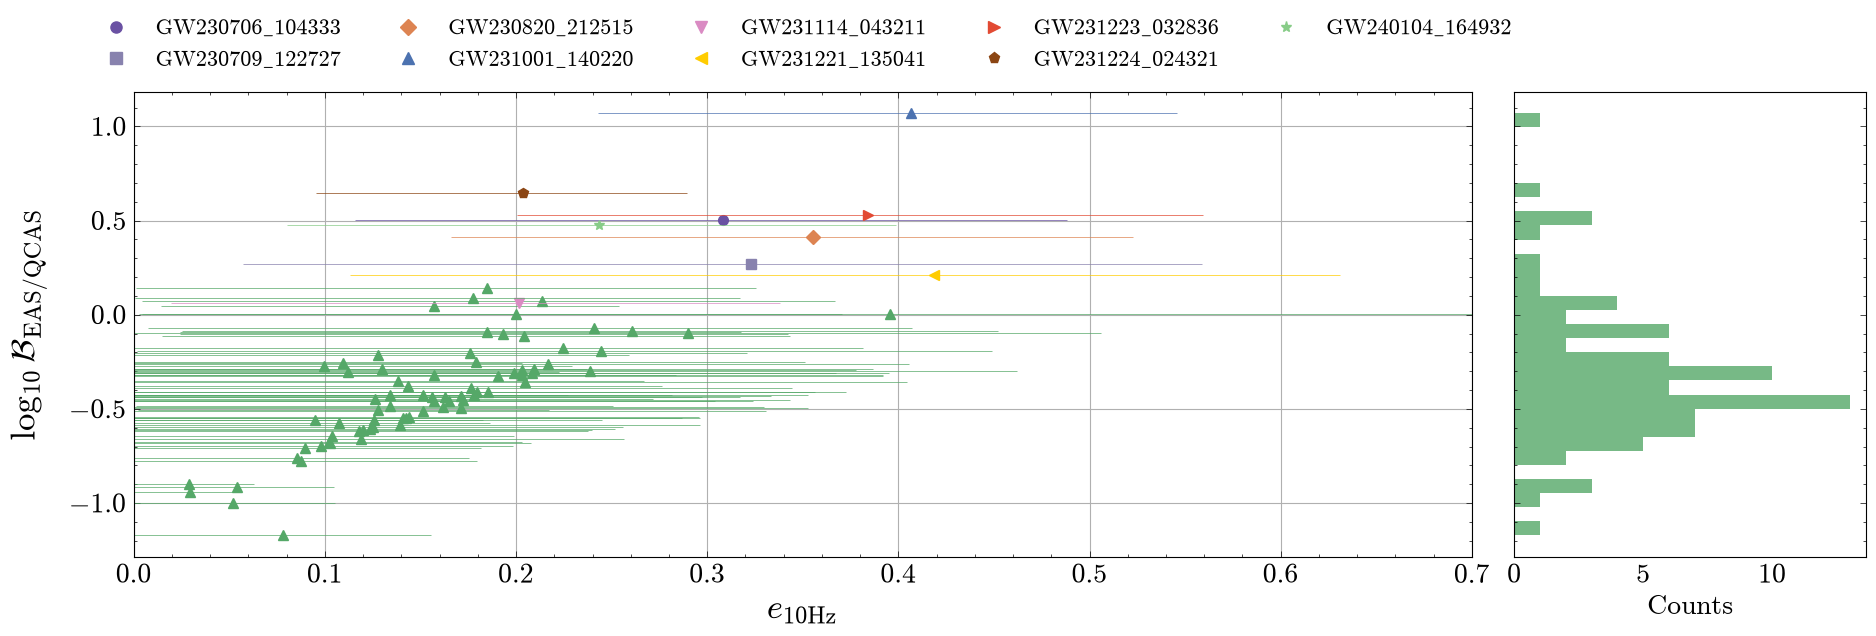

In [6]:
fig, ax_main, ax_hist, log10_bf_dict = plot_events_hdi_vs_bayes(table_stats, threshold_bf=0.15, bins=30)
fig.savefig('../figures/bf_lineplot.pdf', bbox_inches='tight', dpi=300)